---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 4. Метод контурних струмів</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Метод контурних струмів</li>
  <li>Алгоритм методу</li>
  <li>Числовий приклад</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 4 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Метод контурних струмів](#mesh-current)
    * [Алгоритм методу](#mesh-current-algorithm)
    * [Числовий приклад](#mesh-current-example)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

## Метод контурних струмів <a class="anchor" id="mesh-current"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати сутність методу контурних струмів
> - Визначати незалежні контури схеми
> - Складати систему рівнянь контурних струмів
> - Знаходити реальні струми у гілках через контурні струми

</div>

### Алгоритм методу <a class="anchor" id="mesh-current-algorithm"></a>

1. Визначити кількість незалежних контурів: $k = m - n + 1$
2. Вибрати незалежні контури та напрямки обходу (зазвичай за годинниковою стрілкою)
3. Для кожного контуру скласти рівняння: **власний опір × власний струм − суміжний опір × суміжний струм = ЕРС контуру**
4. Розв'язати систему рівнянь
5. Знайти реальні струми як алгебраїчну суму контурних струмів

**Матрична форма:** $[R] \cdot [I] = [E]$



---
### Числовий приклад <a class="anchor" id="mesh-current-example"></a>

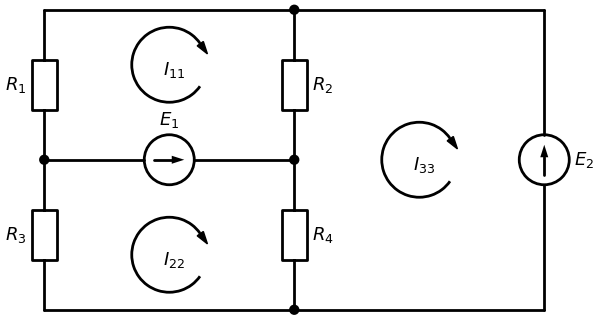

In [2]:
# Схема: метод контурних струмів — три незалежні контури, контурні струми за годинниковою стрілкою
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:

        T0, L, M, B0 = (0, 6), (0, 3), (5, 3), (0, 0)
        R1 = d.add(elm.Resistor().at(T0).down().label('$R_1$', loc='top'))
        Ln = d.add(elm.Dot())
        R3 = d.add(elm.Resistor().down().label('$R_3$', loc='top'))
        d.add(elm.Line().right(5))
        Bn = d.add(elm.Dot())
        d.add(elm.Line().right(5))
        E2 = d.add(EMF().up(6).label('$E_2$', loc='bottom'))
        d.add(elm.Line().left(5))
        Tn = d.add(elm.Dot())
        d.add(elm.Line().left(5))
        E1 = d.add(EMF().at(L).right(5).label('$E_1$'))
        Mn = d.add(elm.Dot())
        R2 = d.add(elm.Resistor().at(Tn.center).down().label('$R_2$', loc='bottom'))
        R4 = d.add(elm.Resistor().at(M).down().label('$R_4$', loc='bottom'))

        for xy, name in [((2.5, 4.9), 'I_{11}'), ((2.5, 1.1), 'I_{22}'), ((7.5, 3), 'I_{33}')]:
            d.add(elm.LoopArrow(direction='cw', width=1.5, height=1.5).at(xy))
            d.add(elm.Label().at(xy).label(f'${name}$'))

Запишемо систему рівнянь:

$$ 
\begin{cases} 
I_{11} \cdot (R_1 + R_2) - I_{33} \cdot R_2 = -E_1 \\
I_{22} \cdot (R_3 + R_4) - I_{33} \cdot R_4 = E_1 \\
I_{33} \cdot (R_2 + R_4) - I_{11} \cdot R_2 - I_{22} \cdot R_4 = -E_2
\end{cases}
$$

Виконаємо символьний розрахунок з використанням `SymPy`:

In [3]:
# Крок 1: параметри кола
E1_s = 60;
E2_s = 30;

R1_s = 10;
R2_s = 40;
R3_s = 10;
R4_s = 30;

E1 = smp.symbols('E1')
E2 = smp.symbols('E2')
R1 = smp.symbols('R1')
R2 = smp.symbols('R2')
R3 = smp.symbols('R3')
R4 = smp.symbols('R4')

I11 = smp.symbols('I11')
I22 = smp.symbols('I22')
I33 = smp.symbols('I33')

# Крок 2: система рівнянь
eq = [I11 * (R1 + R2) - I33 * R2 + E1,  
      I22 * (R3 + R4) - I33 * R4 - E1, 
      I33 * (R2 + R4) - I11 * R2 - I22 * R4 + E2]

# Крок 3: розв'язуємо систему рівнянь
sol = smp.solve(eq, [I11, I22, I33])
sol

{I11: (-E1*R2*R3 - E1*R3*R4 - E2*R2*R3 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4),
 I22: (E1*R1*R2 + E1*R1*R4 - E2*R1*R4 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4),
 I33: (E1*R1*R4 - E1*R2*R3 - E2*R1*R3 - E2*R1*R4 - E2*R2*R3 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4)}

Перший контурний струм $I_{11}$:

In [4]:
sol[I11]

(-E1*R2*R3 - E1*R3*R4 - E2*R2*R3 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4)

Другий контурний струм $I_{22}$:

In [5]:
sol[I22]

(E1*R1*R2 + E1*R1*R4 - E2*R1*R4 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4)

Третій контурний струм $I_{33}$:

In [6]:
sol[I33]

(E1*R1*R4 - E1*R2*R3 - E2*R1*R3 - E2*R1*R4 - E2*R2*R3 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4)

Знайдемо, при якому значенні $E_1$ контурний струм $I_{11}$ дорівнює нулю: прирівнюємо вираз для $I_{11}$ до нуля і розв'язуємо відносно $E_1$.

In [7]:
soll1 = smp.solve((-E1*R2*R3 - E1*R3*R4 - E2*R2*R3 - E2*R2*R4)/(R1*R2*R3 + R1*R2*R4 + R1*R3*R4 + R2*R3*R4), E1)
print(soll1)
print(soll1[0].subs(E2, E2_s).subs(R1, R1_s).subs(R2, R2_s).subs(R3, R3_s).subs(R4, R4_s))


[E2*R2*(-R3 - R4)/(R3*(R2 + R4))]
-480/7


Розрахуємо числові значення контурних струмів — точні (звичайні дроби) та десяткові:

In [8]:
I11_s = sol[I11].subs(E1, E1_s).subs(E2, E2_s).subs(R1, R1_s).subs(R2, R2_s).subs(R3, R3_s).subs(R4, R4_s)
I22_s = sol[I22].subs(E1, E1_s).subs(E2, E2_s).subs(R1, R1_s).subs(R2, R2_s).subs(R3, R3_s).subs(R4, R4_s)
I33_s = sol[I33].subs(E1, E1_s).subs(E2, E2_s).subs(R1, R1_s).subs(R2, R2_s).subs(R3, R3_s).subs(R4, R4_s)

for name, val in [('I11', I11_s), ('I22', I22_s), ('I33', I33_s)]:
    print(f'{name} = {val} = {float(val):.4f} А')

I11 = -90/31 = -2.9032 А
I22 = -3/31 = -0.0968 А
I33 = -66/31 = -2.1290 А


Позначимо на схемі струми гілок $I_1 \ldots I_6$ і номери вузлів, які використовуються в моделі PySpice нижче (вузол 0 — «земля»):

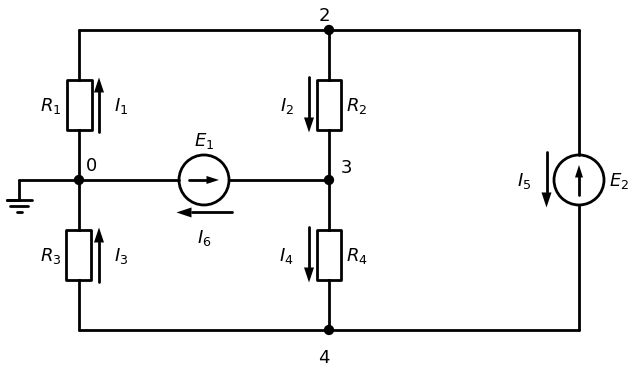

In [9]:
# Схема: струми гілок та номери вузлів, які використано в моделі PySpice нижче (вузол 0 — «земля»)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:

        T0, L, M, B0 = (0, 6), (0, 3), (5, 3), (0, 0)
        R1 = d.add(elm.Resistor().at(T0).down().label('$R_1$', loc='top'))
        Ln = d.add(elm.Dot())
        R3 = d.add(elm.Resistor().down().label('$R_3$', loc='top'))
        d.add(elm.Line().right(5))
        Bn = d.add(elm.Dot())
        d.add(elm.Line().right(5))
        E2 = d.add(EMF().up(6).label('$E_2$', loc='bottom'))
        d.add(elm.Line().left(5))
        Tn = d.add(elm.Dot())
        d.add(elm.Line().left(5))
        E1 = d.add(EMF().at(L).right(5).label('$E_1$'))
        Mn = d.add(elm.Dot())
        R2 = d.add(elm.Resistor().at(Tn.center).down().label('$R_2$', loc='bottom'))
        R4 = d.add(elm.Resistor().at(M).down().label('$R_4$', loc='bottom'))

        d.add(elm.CurrentLabel(top=True, length=1.1, reverse=True).at(R1).label('$I_1$'))
        d.add(elm.CurrentLabel(top=False, length=1.1).at(R2).label('$I_2$'))
        d.add(elm.CurrentLabel(top=True, length=1.1, reverse=True).at(R3).label('$I_3$'))
        d.add(elm.CurrentLabel(top=False, length=1.1).at(R4).label('$I_4$'))
        d.add(elm.CurrentLabel(top=True, length=1.1, reverse=True).at(E2).label('$I_5$'))
        d.add(elm.CurrentLabel(top=False, length=1.1, reverse=True).at(E1).label('$I_6$'))
        d.add(elm.Line().at(Ln.center).left(1.2))
        d.add(elm.Ground())
        d.add(elm.Label().at((0.35, 3.4)).label('0'))
        d.add(elm.Label().at((5, 6.4)).label('2'))
        d.add(elm.Label().at((5.45, 3.35)).label('3'))
        d.add(elm.Label().at((5, -0.45)).label('4'))

$$
\begin{cases} 
I_1 = I_{11} \\
I_2 = I_{11} - I_{33} \\
I_3 = I_{22} \\
I_4 = I_{22} - I_{33} \\
I_5 = I_{33} \\
I_6 = I_{11} - I_{22}
\end{cases} 
$$

Розрахуємо значення струмів в контурах:

In [10]:
I1 = I11
I2 = I11 - I33
I3 = I22
I4 = I22 - I33
I5 = I33
I6 = I11 - I22

Підставимо числові значення контурних струмів і отримаємо струми гілок — точні значення (звичайні дроби) та десяткові:

In [11]:
for name, expr in [('I1', I1), ('I2', I2), ('I3', I3), ('I4', I4), ('I5', I5), ('I6', I6)]:
    val = expr.subs(I11, I11_s).subs(I22, I22_s).subs(I33, I33_s)
    print(f'{name} = {val} = {float(val):.4f} А')

I1 = -90/31 = -2.9032 А
I2 = -24/31 = -0.7742 А
I3 = -3/31 = -0.0968 А
I4 = 63/31 = 2.0323 А
I5 = -66/31 = -2.1290 А
I6 = -87/31 = -2.8065 А


Зберемо електричну схему в `PySpice` для верифікації:

In [12]:
circuit = Circuit('Cont')

V1 = circuit.V('V1', 3, circuit.gnd, 60@u_V)
V2 = circuit.V('V2', 2, 4, 30@u_V)

R1 = circuit.R('R1', circuit.gnd, 2, 10@u_Ω)
R2 = circuit.R('R2', 2, 3, 40@u_Ω)
R3 = circuit.R('R3', circuit.gnd, 4, 10@u_Ω)
R4 = circuit.R('R4', 3, 4, 30@u_Ω)

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.operating_point()

2026-10-09 10:24:53,815 - PySpice.Spice.NgSpice.Shared.NgSpiceShared._init_ngspice - WARNING - Unsupported Ngspice version 42


Струм $I_{2}$ в гілці:

In [13]:
(analysis['2']-analysis['3'])/40

WaveForm  [-0.77419355]@V

Струм $I_{4}$ в гілці:

In [14]:
(analysis['3']-analysis['4'])/30

WaveForm  [2.03225806]@V

$$ I_{11} \cdot ( R_1 + R_2) - I_{22} \cdot R_2 = E_1 - E_2 $$

$$ I_{22} \cdot ( R_2 + R_3) - I_{11} \cdot R_2 = E_2 $$

$$ I_{22} \cdot ( R_2 + R_3) = I_{11} \cdot R_2 + E_2 $$

$$ I_{22} = \cfrac{ I_{11} \cdot R_2 + E_2}{R_2 + R_3} $$

$$ I_{11} \cdot( ( R_1 + R_2) - \cfrac{ R_2 + E_2}{R_2 + R_3} \cdot R_2) = E_1 - E_2 $$

$$ I_{11} = \cfrac{E_1 - E_2}{ ( R_1 + R_2) - \cfrac{ R_2 + E_2}{R_2 + R_3} \cdot R_2} $$

$$ I_{22} \cdot ( R_2 + R_3) = \cfrac{E_1 - E_2}{ ( R_1 + R_2) - \cfrac{ R_2 + E_2}{R_2 + R_3} \cdot R_2} \cdot R_2 + E_2 $$

$$ I_{22} = \cfrac{\cfrac{E_1 - E_2}{ ( R_1 + R_2) - \cfrac{ R_2 + E_2}{R_2 + R_3} \cdot R_2} \cdot R_2 + E_2}{R_2 + R_3} $$

$$ I_1 = I_{11}$$

$$ I_2 = I_{11} - I_{22}$$

$$ I_3 = I_{22}$$


---

### 📌 Підсумок: Метод контурних струмів

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Система рівнянь для двох контурів:**

$$\begin{cases} I_{11}(R_{11}) - I_{22}(R_{12}) = E_{11} \\ I_{22}(R_{22}) - I_{11}(R_{12}) = E_{22} \end{cases}$$

де:
- $R_{ii}$ — власний опір $i$-го контуру (сума опорів у контурі)
- $R_{ij}$ — взаємний опір між контурами $i$ та $j$ (спільний опір)
- $E_{ii}$ — алгебраїчна сума ЕРС у $i$-му контурі

**Порівняння методів:**

| Критерій | Метод вузлових потенціалів | Метод контурних струмів |
|---------|--------------------------|------------------------|
| Кількість рівнянь | $n-1$ | $m-n+1$ |
| Ефективний для | Паралельних кіл | Послідовних кіл |
| Невідомі | Потенціали вузлів $\varphi$ | Контурні струми $I$ |

</div>

---


In [15]:
# Інтерактивний метод контурних струмів (2 контури)
def mesh_current_interactive(E1=60, E2=30, R1=10, R2=40, R3=10, R4=30):
    I11s, I22s = smp.symbols('I11 I22')
    eq1 = I11s*(R1 + R2) - I22s*R2 + E1
    eq2 = I22s*(R2 + R3 + R4) - I11s*R2 - E1 + E2
    sol = smp.solve([eq1, eq2], [I11s, I22s])
    i11, i22 = float(sol[I11s]), float(sol[I22s])

    # струми гілок
    iR1 = i11
    iR2 = i11 - i22
    iR3 = i22
    iR4 = i22

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    names_c = ['I11 (контур 1)', 'I22 (контур 2)']
    vals_c = [i11, i22]
    c_colors = ['#2196F3' if v >= 0 else '#F44336' for v in vals_c]
    ax1.bar(names_c, vals_c, color=c_colors, edgecolor='k')
    ax1.axhline(0, color='k', lw=0.8)
    ax1.set_title('Контурні струми (А)')
    ax1.set_ylabel('Струм, А')
    for bar, val in zip(ax1.patches, vals_c):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
                 f'{val:.3f}', ha='center', fontsize=10)

    names_b = ['iR1', 'iR2', 'iR3', 'iR4']
    vals_b = [iR1, iR2, iR3, iR4]
    b_colors = ['#4CAF50' if v >= 0 else '#F44336' for v in vals_b]
    ax2.bar(names_b, vals_b, color=b_colors, edgecolor='k')
    ax2.axhline(0, color='k', lw=0.8)
    ax2.set_title('Струми гілок (А)')
    ax2.set_ylabel('Струм, А')

    plt.suptitle(f'I11={i11:.3f} A, I22={i22:.3f} A', fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'Контурні струми: I11 = {i11:.4f} А, I22 = {i22:.4f} А')
    print(f'Струми гілок: iR1={iR1:.4f}, iR2={iR2:.4f}, iR3={iR3:.4f}, iR4={iR4:.4f} А')
    print(f'Потужності: P_E1={E1*(-i11):.2f} Вт, P_E2={E2*i22:.2f} Вт')

interact(mesh_current_interactive,
         E1=widgets.FloatSlider(min=10, max=120, step=5, value=60, description='E1 (В)'),
         E2=widgets.FloatSlider(min=0, max=60, step=5, value=30, description='E2 (В)'),
         R1=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='R1 (Ом)'),
         R2=widgets.FloatSlider(min=1, max=100, step=1, value=40, description='R2 (Ом)'),
         R3=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='R3 (Ом)'),
         R4=widgets.FloatSlider(min=1, max=100, step=1, value=30, description='R4 (Ом)'))

interactive(children=(FloatSlider(value=60.0, description='E1 (В)', max=120.0, min=10.0, step=5.0), FloatSlide…

<function __main__.mesh_current_interactive(E1=60, E2=30, R1=10, R2=40, R3=10, R4=30)>

---
### ⚡ Практичне застосування: Метод контурних струмів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Застосування у проектуванні ВЧ-схем:**

Метод контурних струмів є ефективним при аналізі **резонансних LC-контурів** і **трансформаторних схем**:

- **Смуговий фільтр (Band-Pass Filter):** Два зв'язані LC-контури — система двох контурних рівнянь описує передавальну функцію фільтра.
- **Трансформатор з розсіюванням:** Взаємний опір $M = j\omega M_{12}$ з'являється у позадіагональних елементах матриці.
- **Коаксіальний кабель:** Еквівалентна схема у вигляді довгого ланцюжка LC-контурів — матрична форма методу.

**Матрична форма:**
$$[Z] \cdot [I] = [E]$$
де $[Z]$ — матриця опорів контурів, $[I]$ — вектор контурних струмів, $[E]$ — вектор контурних ЕРС.

> Метод ефективний, коли **кількість контурів** ($m - n + 1$) менша за кількість вузлів.

</div>

---
### ✅ Питання для самоперевірки: Метод контурних струмів

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що таке власний і взаємний опір контуру?</summary>

> **Відповідь:** Власний опір $Z_{ii}$ — сума всіх опорів у $i$-му контурі. Взаємний опір $Z_{ij}$ — сума спільних опорів між контурами $i$ та $j$ (береться зі знаком «−», якщо контурні струми течуть через спільний опір у протилежних напрямках).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Коли метод контурних струмів ефективніший за метод вузлових потенціалів?</summary>

> **Відповідь:** Коли кількість незалежних контурів $m - n + 1$ менша за кількість незалежних вузлів $n - 1$. Наприклад, для схем із малою кількістю контурів, але з великою кількістю вузлів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як увести у рівняння ідеальне джерело струму в контурному методі?</summary>

> **Відповідь:** Якщо джерело струму $J$ знаходиться у гілці, що входить лише до одного контуру, то контурний струм цього контуру дорівнює $J$ — і відповідне рівняння замінюється цим обмеженням. Для випадку «суперконтуру» (джерело між двома контурами) записується додаткове рівняння.

</details>

---
### 📝 Задачі для самостійного розв'язання: Метод контурних струмів


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Два контури мають спільний резистор $R_3 = 6$ Ом. Власний резистор першого контуру $R_1 = 4$ Ом, другого — $R_2 = 2$ Ом. У першому контурі ЕРС $E_1 = 20$ В діє за напрямком обходу, у другому ЕРС $E_2 = 10$ В — проти напрямку обходу. Обидва контурні струми напрямлені за годинниковою стрілкою. Знайдіть контурні струми і струм у $R_3$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\begin{cases}10I_{11} - 6I_{22} = 20\\ -6I_{11} + 8I_{22} = -10\end{cases}$, $\Delta = 44$.
> $I_{11} = 100/44 \approx 2{,}27$ А, $I_{22} = 20/44 \approx 0{,}45$ А, $I_{R3} = I_{11} - I_{22} \approx 1{,}82$ А.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Схема має $m = 5$ гілок і $n = 3$ вузли. Який метод дасть меншу систему рівнянь — контурних струмів чи вузлових потенціалів?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Контурних струмів: $m - n + 1 = 3$ рівняння; вузлових потенціалів: $n - 1 = 2$ рівняння. Вигідніший метод вузлових потенціалів.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 3. Метод вузлових потенціалів](Тема_03_Метод_вузлових_потенціалів.ipynb) &nbsp;|&nbsp; [Тема 5. Метод еквівалентного генератора. Принцип накладення](Тема_05_Метод_еквівалентного_генератора_та_накладення.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
